# pip

In [1]:
# 標準ライブラリ
from datetime import datetime
import itertools
import warnings
import os

# データハンドリング・数値計算
import numpy as np
import pandas as pd
import joblib

# scikit-learn (機械学習関連)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,

)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV

# 決定木 & PyTorch
import xgboost as xgb
import torch.nn.functional as F

# 可視化
import matplotlib.pyplot as plt

# ハイパーパラメータ最適化
import optuna


C:\Users\takic\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 前処理

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from typing import Tuple, Any, Dict, List, Optional

def prepare_data_for_cv(csv_path: str, lang_feature=False) -> Optional[Tuple[
    np.ndarray, np.ndarray, Dict[str, np.ndarray], np.ndarray, np.ndarray, List[str], LabelEncoder, OrdinalEncoder
]]:
    """
    OptunaのCVループ用にデータを準備します。
    groups情報を含む評価に必要な全てのメタデータを 'meta' 辞書に集約します。
    """
    print("--- 1. Starting Data Processing for CV ---")
    
    try:
        df = pd.read_csv(csv_path)
        df = df[df["day"] == 1]
        df= df.dropna(subset=["attack_id"])
        del_path=df[(df["role"]=="SEER")&(df["True_Div_result_1"].isna())]["source_file"].unique()
        print(f"Excluding {len(del_path)} files with missing True_Div_result_1 for SEER: {del_path}")
        df=df[~df["source_file"].isin(del_path)]
        print(f"Loaded '{csv_path}'. Shape: {df.shape}")
    except Exception as e:
        print(f"Error loading CSV: {e}")
        return None

    # --- 1. テキストと話者名の保持 (TF-IDF / SVC Stacking用) ---
    # 学習には直接使わず、CVループ内での追加特徴量生成に使用
    raw_texts = df['combined_text'].astype(str).values
    agent_names = df['agent_name'].astype(str).values

    # --- 2. 目的変数のエンコード ---
    role_encoder = LabelEncoder()
    df['role'] = role_encoder.fit_transform(df['role'].astype(str))
    y = df['role'].values

    # --- 3. メタデータ辞書の作成 (groups含む) ---
    # 後続の役職割り当てロジックで使用するカラムを抽出
    # True_Div_result_1 が欠損の行を除外

    meta = {
        'source_file': df['source_file'].values,  # これがCVのgroupsになる
        'div_result1': df['True_Div_result_1'].values if 'True_Div_result_1' in df.columns else np.full(len(df), np.nan),
        'div_id1': df['True_Div_recepient_id_1'].values if 'True_Div_recepient_id_1' in df.columns else np.full(len(df), np.nan),
        'div_result2': df['True_Div_result_2'].values if 'True_Div_result_2' in df.columns else np.full(len(df), np.nan),
        'div_id2': df['True_Div_recepient_id_2'].values if 'True_Div_recepient_id_2' in df.columns else np.full(len(df), np.nan),
        'exec_id': df['exec_id'].values if 'exec_id' in df.columns else np.full(len(df), np.nan),
        'attack_id': df['attack_id'].values if 'attack_id' in df.columns else np.full(len(df), np.nan)
    }

    # --- 4. 言語統計特徴量の生成 ---
    if lang_feature and ("combined_text" in df.columns):
        df['text_length'] = df['combined_text'].astype(str).apply(len)
        df['sentence_count'] = df['combined_text'].astype(str).apply(lambda x: x.count('。'))
        df['avg_sentence_length'] = df.apply(
            lambda row: row['text_length'] / row['sentence_count'] if row['sentence_count'] > 0 else 0, axis=1
        )
    

    # --- 5. カテゴリカル特徴量のエンコード ---
    result_like_cols = [c for c in df.columns if c.endswith('_result')]
    categorical_features = [col for col in result_like_cols if col in df.columns]
    
    feature_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=int)

    if categorical_features:
        df[categorical_features] = df[categorical_features].fillna('Missing').astype(str)
        df[categorical_features] = feature_encoder.fit_transform(df[categorical_features])

    # --- 6. 学習用特徴量行列(X)の作成 ---
    base_drop_cols = [
        'id', 'role', 'source_file', 'day', 'role_encoded', 
        'Est_id_Fact_role', 'Est_id_Est_roles', 'character_name', 
        'agent_name', 'combined_text', 'seer_co_order'
    ]
    # metaに入れたカラムもXからは除外（データリーク防止）
    meta_raw_cols = [
        'True_Div_result_1', 'True_Div_recepient_id_1',
        'True_Div_result_2', 'True_Div_recepient_id_2',
        'exec_id', 'attack_id'
    ]
    day2_col =[c for c in df.columns if c.startswith('day1_') or c.startswith('day2_') ]
    id_like_cols = [c for c in df.columns if c.endswith('_id')]
    flag_like_cols = [c for c in df.columns if c.endswith('_flag')]
    
    all_drop_cols = list(set(base_drop_cols + meta_raw_cols + id_like_cols + flag_like_cols+ day2_col))
    
    X_df = df.drop(columns=all_drop_cols, errors='ignore')
    final_features = X_df.columns.tolist()
    X = X_df.apply(pd.to_numeric, errors='coerce').fillna(0).values

    print(f"Final feature shape: {X.shape}. Groups: {len(np.unique(meta['source_file']))} games.")
    
    return X, y, meta, raw_texts, agent_names, final_features, role_encoder, feature_encoder

In [6]:
X,y,meta,raw_texts,agent_names,final_features,label_encoder,feature_encoder = prepare_data_for_cv(r"../..//..//data//all_feature_table_2025sm_with_talks.csv")
print("--- Returned Data Shapes ---")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}\n")

--- 1. Starting Data Processing for CV ---
Excluding 7 files with missing True_Div_result_1 for SEER: ['taged_1756135239_CamelliaDragons_CanisLupus_Character-Lab_GPTaku_sunamelli.log'
 'taged_1756138232_CamelliaDragons_CanisLupus_Character-Lab_GPTaku_sunamelli.log'
 'taged_1756185996_CamelliaDragons_CanisLupus_Character-Lab_GPTaku_mille.log'
 'taged_1756201253_CamelliaDragons_CanisLupus_Character-Lab_kanolab-nw_mille.log'
 'taged_1756239822_CamelliaDragons_GPTaku_kanolab-nw_mille_yharada.log'
 'taged_1756249485_CamelliaDragons_CanisLupus_GPTaku_kanolab-nw_yharada.log'
 'taged_1756262936_Character-Lab_GPTaku_mille_sunamelli_yharada.log']
Loaded '../..//..//data//all_feature_table_2025sm_with_talks.csv'. Shape: (375, 231)
Final feature shape: (375, 168). Groups: 75 games.
--- Returned Data Shapes ---
X shape: (375, 168)
y shape: (375,)



# 割り当て関数

In [7]:
import numpy as np
import torch
import itertools

def assign_roles_for_non_seer(
    logits, y_batch, role_counts, role_names, label_encoder,
    fixed_self_role_name,
    exec_id_batch, attack_id_batch, day2_flag=True,debag=False):
    # --- 初期設定 ---
    role_names = list(role_names)
    if isinstance(logits, torch.Tensor): logits = logits.detach().cpu().numpy()
    if isinstance(y_batch, torch.Tensor): y_batch = y_batch.detach().cpu().numpy()
    num_players = logits.shape[0]
    if num_players != 5:
        return np.array([]), np.array([])
    
    pred_list, y_list = [], []

    # --- 各プレイヤーを「自分」と仮定してループ ---
    for self_index in range(num_players):
        self_role = y_batch[self_index]
        self_role_name = label_encoder.inverse_transform([self_role])[0]
        
        # 評価対象の役職と実際の役職が一致しない場合はスキップ
        if self_role_name != fixed_self_role_name:
            continue

        if (self_index +1 in exec_id_batch or self_index +1 in attack_id_batch) and day2_flag:
            if debag:
                print(f"skip id:{self_index +1} exec or attack")
            continue

        if exec_id_batch is None or all(x is None for x in exec_id_batch):
            print("all exec_id_batch are None")
            continue

        if attack_id_batch is None or all(x is None for x in attack_id_batch):
            print("all attack_id_batch are None")
            continue
        
        if debag:
            print(f"y_batch:{y_batch}")
        other_indices = [i for i in range(num_players) if i != self_index]
        logits_others = logits[other_indices]
        y_others = y_batch[other_indices]
        
        # --- 制約リストの初期化 ---
        non_werewolf_indices_in_others = []
        # [制約1] 追放者・被襲撃者は人狼ではない
        if day2_flag:
            exec_id = exec_id_batch[self_index]
            attack_id = attack_id_batch[self_index]
            if np.isnan(attack_id) or np.isnan(exec_id): 
                if debag:
                    print(f"id:{self_index +1} skip: NaN in exec or attack")
                continue
            attack_id_idx = int(attack_id) - 1
            exec_id_idx = int(exec_id) - 1
            if self_index == exec_id_idx or self_index == attack_id_idx: 
                if debag:
                    print(f"id:{self_index +1} skip: exec or attack")
                continue
            if exec_id_idx in other_indices:
                non_werewolf_indices_in_others.append(other_indices.index(exec_id_idx))
            if attack_id_idx in other_indices:
                non_werewolf_indices_in_others.append(other_indices.index(attack_id_idx))
            non_werewolf_indices_in_others = list(set(non_werewolf_indices_in_others))
            
        # --- 他プレイヤーの役職プールを作成 ---
        reduced_counts = role_counts.copy()
        if reduced_counts.get(fixed_self_role_name, 0) == 0:
            print(f"Skipping because reduced_counts for {fixed_self_role_name} is 0")
            continue
        reduced_counts[fixed_self_role_name] -= 1
        roles_pool = [role for role, count in reduced_counts.items() for _ in range(count)]
        if len(roles_pool) != 4: 
            print(f"Skipping because roles_pool length is not 4: {len(roles_pool)}")
            continue
            
        # --- 汎用探索ロジック ---
        best_perm = None
        best_score = -np.inf
        # 他4人の役職の組み合わせを全探索
        for perm in set(itertools.permutations(roles_pool)):
            # [制約1] をチェック
            if any(perm[idx] == "WEREWOLF" for idx in non_werewolf_indices_in_others):
                #print(f"Skipping permutation due to WEREWOLF constraint: {perm}")
                continue
            # 制約を満たす組み合わせのスコアを計算
            score = sum(np.log(logits_others[i][role_names.index(role)] + 1e-9) for i, role in enumerate(perm))
            if score > best_score:
                best_score, best_perm = score, perm
                
        # 最適な割り当てが見つかった場合、結果を保存
        if best_perm:
            pred_encoded = label_encoder.transform(list(best_perm))
            pred_list.append(pred_encoded)
            y_list.append(y_others)
            if debag:
                print(f"Best permutation for self_index {self_index}: {best_perm} with score {best_score}")
        else:
            if debag:
                print(f"No valid permutation found for self_index {self_index}")
        
            
    # --- 全ての評価結果を結合して返す ---
    return (np.concatenate(pred_list) if pred_list else np.array([]),
            np.concatenate(y_list) if y_list else np.array([]))

import numpy as np
import torch
import itertools

def assign_roles_for_seer_by_divination(
    logits, y_batch, role_counts, role_names, label_encoder,
    div_result_array1, div_id_array1, div_result_array2=None, div_id_array2=None,
    exec_id_batch=None, attack_id_batch=None, day2_flag=True,debag=False):
    # --- 初期設定 ---
    role_names = list(role_names)
    if isinstance(logits, torch.Tensor): logits = logits.detach().cpu().numpy()
    if isinstance(y_batch, torch.Tensor): y_batch = y_batch.detach().cpu().numpy()
    
    num_players = logits.shape[0]
    if num_players != 5:
        empty_result = (np.array([]), np.array([]))
        return {"black": empty_result, "white": empty_result}

    pred_list_black, y_list_black = [], []
    pred_list_white, y_list_white = [], []

    fixed_self_role_name = "SEER"
    werewolf_label = "WEREWOLF"

    # --- 各プレイヤーを「自分(占い師)」と仮定してループ ---
    for self_index in range(num_players):
        self_role_name = label_encoder.inverse_transform([y_batch[self_index]])[0]

        # 実際の役職が占い師でない場合はスキップ
        if self_role_name != fixed_self_role_name:
            continue
        # 追放者・被襲撃者の場合はスキップ(1日目は考慮しなくていいのでday2_flag=Trueのときのみ)
        if (self_index+1 in exec_id_batch or self_index+1 in attack_id_batch) & day2_flag:
            if debag:
                print(f"skip id:{self_index +1} exec or attack")
            continue

        if exec_id_batch is None or all(x is None for x in exec_id_batch) & day2_flag:
            print("all exec_id_batch are None")
            continue

        if attack_id_batch is None or all(x is None for x in attack_id_batch) & day2_flag:
            print("all attack_id_batch are None")
            continue

        if div_id_array1 is None or all(np.isnan(div_id_array1)):
            print("all div_id_array1 are None")
            continue
        if debag:
            print(f"y_batch:{y_batch}")
        other_indices = [i for i in range(num_players) if i != self_index]
        logits_others = logits[other_indices]
        y_others = y_batch[other_indices]

        # --- 制約リストの初期化 ---
        non_werewolf_indices_in_others = []
        div_constraints = {}  # {target_idx_in_others: "WEREWOLF" or "HUMAN"}

        # [制約1] 追放者・被襲撃者は人狼ではない
        if day2_flag and exec_id_batch is not None and attack_id_batch is not None:
            exec_id = exec_id_batch[self_index]
            attack_id = attack_id_batch[self_index]
            if not (np.isnan(exec_id) or np.isnan(attack_id)):
                exec_id_idx = int(exec_id) - 1
                attack_id_idx = int(attack_id) - 1
            else:
                continue
            if exec_id_idx in other_indices:
                non_werewolf_indices_in_others.append(other_indices.index(exec_id_idx))
            if attack_id_idx in other_indices:
                non_werewolf_indices_in_others.append(other_indices.index(attack_id_idx))
            non_werewolf_indices_in_others = list(set(non_werewolf_indices_in_others))
        
        # [制約2] 占い結果を収集
        all_div_results = [(div_result_array1, div_id_array1)]
        if day2_flag and div_result_array2 is not None and div_id_array2 is not None:
            all_div_results.append((div_result_array2, div_id_array2))

        first_div_result_for_classification = None # 1日目の占い結果を分類に使う

        for i, (div_result_array, div_id_array) in enumerate(all_div_results):
            if np.isnan(div_id_array[self_index]): continue
            
            div_id = int(div_id_array[self_index]) - 1
            if div_id not in other_indices: continue
                
            div_target_index_in_others = other_indices.index(div_id)
            div_result_str = str(div_result_array[self_index]).strip()

            div_logic_result = None
            if div_result_str in ["WEREWOLF", "人狼", "黒"]:
                div_logic_result = "WEREWOLF"
            elif div_result_str in ["HUMAN", "白", "not(人狼)"]:
                div_logic_result = "HUMAN"
            
            if div_logic_result:
                div_constraints[div_target_index_in_others] = div_logic_result
                if i == 0: # 1日目の占い結果を保存
                    first_div_result_for_classification = div_logic_result
        
        # 評価の基準となる1日目の占い結果がなければスキップ
        if first_div_result_for_classification is None:
            continue

        # --- 他プレイヤーの役職プールを作成 ---
        reduced_counts = role_counts.copy()
        if reduced_counts.get(fixed_self_role_name, 0) == 0: continue
        reduced_counts[fixed_self_role_name] -= 1
        roles_pool = [role for role, count in reduced_counts.items() for _ in range(count)]
        if len(roles_pool) != 4: continue

        # --- [探索ロジック] 全ての制約を満たす最適な役職割り当てを探索 ---
        best_score, best_perm = -np.inf, None

        for perm in set(itertools.permutations(roles_pool)):
            is_valid = True
            
            # [チェック1] 追放者・被襲撃者制約
            if any(perm[idx] == werewolf_label for idx in non_werewolf_indices_in_others):
                continue
                
            # [チェック2] 占い結果制約
            for target_idx, result in div_constraints.items():
                if result == "WEREWOLF" and perm[target_idx] != werewolf_label:
                    is_valid = False; break
                if result == "HUMAN" and perm[target_idx] == werewolf_label:
                    is_valid = False; break
            if not is_valid: continue

            # スコア計算
            score = sum(np.log(logits_others[i][role_names.index(role)] + 1e-9) for i, role in enumerate(perm))
            if score > best_score:
                best_score, best_perm = score, perm

        # --- 1日目の占い結果に基づき、最適な組み合わせをリストに追加 ---
        if best_perm:
            pred_encoded = label_encoder.transform(list(best_perm))
            if first_div_result_for_classification == "WEREWOLF":
                pred_list_black.append(pred_encoded)
                y_list_black.append(y_others)
            elif first_div_result_for_classification == "HUMAN":
                pred_list_white.append(pred_encoded)
                y_list_white.append(y_others)

    # --- 全ての評価結果を結合して辞書形式で返す ---
    result = {
        "black": (np.concatenate(pred_list_black) if pred_list_black else np.array([]),
                  np.concatenate(y_list_black) if y_list_black else np.array([])),
        "white": (np.concatenate(pred_list_white) if pred_list_white else np.array([]),
                  np.concatenate(y_list_white) if y_list_white else np.array([])),
        "div_result": (div_result_array1, div_id_array1)
    }
    return result

# 学習

## 話者推定特徴量

In [8]:
def compute_speaker_features_with_oof(df, n_splits=5):
    """
    Out-Of-Fold方式で話者確率特徴量を計算（データリークを防ぐ）
    """
    
    agent_le = LabelEncoder()
    agent_le.fit(df['agent_name'])
    y = agent_le.transform(df['agent_name'])
    classes = agent_le.classes_
    
    # OOF予測用の配列を初期化
    oof_probs = np.zeros((len(df), len(classes)))
    
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=2000, token_pattern=None)
    tfidf_all = vectorizer.fit_transform(df['combined_text'].astype(str)).toarray()
    
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, val_idx in cv.split(tfidf_all, y):
        X_train_fold, X_val_fold = tfidf_all[train_idx], tfidf_all[val_idx]
        y_train_fold = y[train_idx]
        
        params = {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 42}
        model = xgb.XGBClassifier(**params, eval_metric='mlogloss')
        calibrated = CalibratedClassifierCV(estimator=model, cv=3)
        calibrated.fit(X_train_fold, y_train_fold)
        
        # Validation foldの予測
        oof_probs[val_idx] = calibrated.predict_proba(X_val_fold)
    
    # 確率列を追加（数値列のみ）
    df_result = df.copy()
    for i, class_name in enumerate(classes):
        df_result[f'prob_class_{class_name}'] = oof_probs[:, i]
    
    # predicted_classは文字列なので追加しない（または使わない）
    # df_result['predicted_class'] = [classes[np.argmax(p)] for p in oof_probs
    return df_result

## 一気通貫コード

In [20]:
# ======================================================================
# Part 2: 学習・最適化パイプラインの定義
# ======================================================================

def train_perspective_model_with_cached_speaker_features(target_view, X, y, meta, raw_texts, agent_names, final_features, label_encoder, n_trials=100, day2_flag=False):
    """
    話者推定特徴量を事前計算してキャッシュすることでCV処理を高速化
    """
    print(f"\n>>> Optimizing model for: {target_view} view")
    
    # === 事前計算: 全データに対して話者確率特徴量を1回だけ計算 ===
    print("Pre-computing speaker probability features (this may take a while)...")
    df_full = pd.DataFrame(X, columns=final_features)
    df_full['combined_text'] = raw_texts
    df_full['agent_name'] = agent_names
    
    # 全データでOOF (Out-Of-Fold) 予測を実行
    df_full_with_probs = compute_speaker_features_with_oof(df_full, n_splits=5)
    
    # 文字列列を除外して数値列のみを取得
    prob_cols = [col for col in df_full_with_probs.columns if col.startswith('prob_class_')]
    X_enhanced = np.hstack([X, df_full_with_probs[prob_cols].values])
    
    print(f"Original X shape: {X.shape}, Enhanced X shape: {X_enhanced.shape}")
    print(f"Added {len(prob_cols)} probability features")
    
    # === 以降は通常のCV処理 ===
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    weight_dict = dict(zip(classes, weights))
    groups = meta['source_file']

    def objective(trial):
        params = {
            'objective': 'multi:softprob',
            'num_class': len(classes),
            'eval_metric': 'mlogloss',
            'booster': 'gbtree',
            'enable_categorical': True,
            'tree_method': 'hist',
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'n_estimators': 2000,
            'gamma': trial.suggest_float('gamma', 0.01, 5.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state': 42,
        }

        sgkf = StratifiedGroupKFold(n_splits=5)
        cv_scores = []
        best_iterations = []

        for train_idx, val_idx in sgkf.split(X, y, groups):
            # 事前計算済みの特徴量を使用（話者推定の再計算なし）
            X_tr, X_val = X_enhanced[train_idx], X_enhanced[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            meta_val = {k: v[val_idx] for k, v in meta.items()}
            
            w_tr = np.array([weight_dict[label] for label in y_tr])
            
            model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
            model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)], verbose=False)
            
            best_iterations.append(model.get_booster().best_iteration)
            preds_proba = model.predict_proba(X_val)
            
            # 役職割り当てロジックによる評価
            all_p, all_t = [], []
            num_games = len(y_val) // 5
            role_counts = {'POSSESSED': 1, 'SEER': 1, 'VILLAGER': 2, 'WEREWOLF': 1}
            class_names = list(label_encoder.classes_)
            
            for i in range(num_games):
                s, e = i*5, (i+1)*5
                if target_view == "SEER":
                    res = assign_roles_for_seer_by_divination(
                        preds_proba[s:e], y_val[s:e], role_counts, class_names, label_encoder,
                        meta_val['div_result1'][s:e], meta_val['div_id1'][s:e],
                        meta_val['div_result2'][s:e], meta_val['div_id2'][s:e],
                        meta_val['exec_id'][s:e], meta_val['attack_id'][s:e], day2_flag
                    )
                    for k in ['black', 'white']:
                        if res[k][0].size > 0:
                            all_p.extend(res[k][0]); all_t.extend(res[k][1])
                else:
                    p, t = assign_roles_for_non_seer(
                        preds_proba[s:e], y_val[s:e], role_counts, class_names, label_encoder, 
                        target_view, meta_val['exec_id'][s:e], meta_val['attack_id'][s:e], day2_flag
                    )
                    if p.size > 0: all_p.extend(p); all_t.extend(t)

            target_label = 'POSSESSED' if target_view == 'WEREWOLF' else 'WEREWOLF'
            score = f1_score(all_t, all_p, labels=[label_encoder.transform([target_label])[0]], average='macro', zero_division=0)
            cv_scores.append(score)

        trial.set_user_attr("best_iteration", int(np.mean(best_iterations)))
        return np.mean(cv_scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    
    # 最終モデルの学習
    print(f"Best Score: {study.best_value}")
    best_params = study.best_params.copy()
    best_params['objective'] = 'multi:softprob'
    best_params['num_class'] = len(classes)
    best_params['eval_metric'] = 'mlogloss'
    best_params['booster'] = 'gbtree'
    best_params['enable_categorical'] = True
    best_params['tree_method'] = 'hist'
    best_params['random_state'] = 42

    print(f"\nBest Parameters: {best_params}")

    # Display CV scores for best parameters
    sgkf = StratifiedGroupKFold(n_splits=5)
    cv_scores_best = []
    groups = meta['source_file']
    fold_results = []
    
    # IMPORTANT: Use the same n_estimators as in Optuna for fair comparison
    best_params_for_cv = best_params.copy()
    best_params_for_cv['n_estimators'] = 2000  # Same as Optuna

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
        X_tr, X_val = X_enhanced[train_idx], X_enhanced[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        meta_val = {k: v[val_idx] for k, v in meta.items()}
        
        w_tr = np.array([weight_dict[label] for label in y_tr])
        # IMPORTANT: Use early_stopping_rounds=50 (same as Optuna)
        model = xgb.XGBClassifier(**best_params_for_cv, early_stopping_rounds=50)
        model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)], verbose=False)
        
        # IMPORTANT: Use predict_proba without iteration_range (same as Optuna)
        # Early stopping already limits the trees used during prediction
        preds_proba = model.predict_proba(X_val)
        
        all_p, all_t = [], []
        num_games = len(y_val) // 5
        role_counts = {'POSSESSED': 1, 'SEER': 1, 'VILLAGER': 2, 'WEREWOLF': 1}
        class_names = list(label_encoder.classes_)
        
        for i in range(num_games):
            s, e = i*5, (i+1)*5
            if target_view == "SEER":
                res = assign_roles_for_seer_by_divination(
                    preds_proba[s:e], y_val[s:e], role_counts, class_names, label_encoder,
                    meta_val['div_result1'][s:e], meta_val['div_id1'][s:e],
                    meta_val['div_result2'][s:e], meta_val['div_id2'][s:e],
                    meta_val['exec_id'][s:e], meta_val['attack_id'][s:e], day2_flag
                )
                for k in ['black', 'white']:
                    if res[k][0].size > 0:
                        all_p.extend(res[k][0]); all_t.extend(res[k][1])
            else:
                p, t = assign_roles_for_non_seer(
                    preds_proba[s:e], y_val[s:e], role_counts, class_names, label_encoder, 
                    target_view, meta_val['exec_id'][s:e], meta_val['attack_id'][s:e], day2_flag
                )
                if p.size > 0: all_p.extend(p); all_t.extend(t)
        
        target_label = 'POSSESSED' if target_view == 'WEREWOLF' else 'WEREWOLF'
        score = f1_score(all_t, all_p, labels=[label_encoder.transform([target_label])[0]], average='macro', zero_division=0)
        cv_scores_best.append(score)
        fold_results.append({'Fold': fold + 1, 'F1_Score': score})
        print(f"Fold {fold+1} CV Score: {score:.4f}")

    print(f"\nMean CV Score: {np.mean(cv_scores_best):.4f} (+/- {np.std(cv_scores_best):.4f})")
    
    # CSV出力
    results_df = pd.DataFrame(fold_results)
    csv_filename = f"{target_view}_model_result.csv"
    results_df.to_csv(csv_filename, index=False)
    print(f"Results saved to {csv_filename}")
    
    best_params['n_estimators'] = int(study.best_trial.user_attrs["best_iteration"])
    
    # 重複パラメータを避けるため、引数に直接指定しない
    final_model = xgb.XGBClassifier(**best_params)
    w_full = np.array([weight_dict[label] for label in y])
    final_model.fit(X_enhanced, y, sample_weight=w_full)
    
    return final_model

# ======================================================================
# Part 3: 実行（一気通貫）
# ======================================================================
# 1. 各モデルの学習
models = {}
for view in ["SEER", "WEREWOLF", "VILLAGER","POSSESSED"]: # VILLAGERはPOSSESSEDと共通想定
    models[view] = train_perspective_model_with_cached_speaker_features(view, X, y, meta, raw_texts, agent_names, final_features, label_encoder, n_trials=100,day2_flag=True)

# 3. 保存
if not os.path.exists("cv_models"):
    os.makedirs("cv_models")
#joblib.dump(models, "cv_models//werewolf_perspective_models.joblib")
print("\nAll models saved successfully.")



>>> Optimizing model for: SEER view
Pre-computing speaker probability features (this may take a while)...


KeyboardInterrupt: 

In [33]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# モデルをロード
print("モデルをロード中...")
model_path = r"werwolf_perspective_models_nospeaker.joblib"
models_data = joblib.load(model_path)

print(f"\nロードされたデータの型: {type(models_data)}")
print(f"含まれるキー: {models_data.keys() if isinstance(models_data, dict) else 'Not a dict'}")

# エージェント情報を読み込む
agent_summary = pd.read_csv(r"agent_role_summary.csv")
fold_assignment = pd.read_csv(r"fold_agent_assignment.csv")

print("\n=== エージェント別の役職数サマリー ===")
print(agent_summary)

# モデルの予測結果を読み込む
roles = ['POSSESSED', 'SEER', 'VILLAGER', 'WEREWOLF']
print("\n=== 各役職モデルの予測結果（F1スコア） ===")

for role in roles:
    result_file = f"{role}_model_result_nospeaker.csv"
    
    try:
        result_df = pd.read_csv(result_file)
        print(f"\n--- {role} モデルの結果 ---")
        print(result_df)
        
        # F1スコアの平均を計算
        if 'F1_Score' in result_df.columns:
            avg_f1 = result_df['F1_Score'].mean()
            print(f"平均F1スコア: {avg_f1:.4f}")
    except Exception as e:
        print(f"{role}の結果ファイルが見つかりません: {e}")

# モデル構造の詳細を確認
print("\n=== モデル構造の詳細 ===")
if isinstance(models_data, dict):
    for key, value in models_data.items():
        print(f"\nモデル視点: {key}")
        print(f"  型: {type(value)}")
        if hasattr(value, 'classes_'):
            print(f"  予測可能なクラス: {value.classes_}")
        if hasattr(value, 'n_classes_'):
            print(f"  クラス数: {value.n_classes_}")

# 実際のモデルを使って予測を実行し、詳細な結果を表示
# 注：割り当て関数内で自視点選択時に脱落者（exec_id, attack_id）を自動的に除外
# Fold別分析も割り当て関数経由の予測を使用
print("\n" + "="*80)
print("=== 各役職視点モデルの詳細な予測結果 ===")
print("=== （割り当て時に脱落者を自視点から除外） ===")
print("="*80)

sgkf_test = StratifiedGroupKFold(n_splits=5)
groups_test = meta['source_file']

# 役職のマッピング（label_encoderから取得）
role_names = label_encoder.classes_
print(f"\n役職一覧: {role_names}")

# 各役職視点モデルで予測を実行
for target_view in models_data.keys():
    print(f"\n{'='*80}")
    print(f"=== {target_view} 視点モデルの予測 ===")
    print(f"{'='*80}")
    model = models_data[target_view]
    
    # 全Foldで予測を実行（割り当て関数経由）
    all_y_true_assigned = []
    all_y_pred_assigned = []
    all_agents_assigned = []
    all_folds_assigned = []
    
    # 全Foldで通常の予測も記録（比較用）
    all_y_true_direct = []
    all_y_pred_direct = []
    all_agents_direct = []
    all_folds_direct = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(sgkf_test.split(X, y, groups_test)):
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]
        agents_val_fold = agent_names[val_idx]
        meta_val_fold = {k: v[val_idx] for k, v in meta.items()}
        
        # モデルで予測実行
        y_pred_proba = model.predict_proba(X_val_fold)
        y_pred_direct = model.predict(X_val_fold)
        
        # 直接予測の結果を記録
        all_y_true_direct.extend(y_val_fold)
        all_y_pred_direct.extend(y_pred_direct)
        all_agents_direct.extend(agents_val_fold)
        all_folds_direct.extend([fold_idx + 1] * len(y_val_fold))
        
        # 割り当て関数を使用（自視点選択時に脱落者を除外）
        num_games = len(y_val_fold) // 5
        role_counts = {'POSSESSED': 1, 'SEER': 1, 'VILLAGER': 2, 'WEREWOLF': 1}
        class_names = list(role_names)
        
        for game_idx in range(num_games):
            start_idx = game_idx * 5
            end_idx = start_idx + 5
            
            # このゲームの5人分のデータ
            game_proba = y_pred_proba[start_idx:end_idx]
            game_y_true = y_val_fold[start_idx:end_idx]
            game_agents = agents_val_fold[start_idx:end_idx]
            exec_id = meta_val_fold['exec_id'][start_idx]
            attack_id = meta_val_fold['attack_id'][start_idx]
            
            if target_view == "SEER":
                # SEER視点の割り当て（脱落者除外あり）
                res = assign_roles_for_seer_by_divination(
                    game_proba, game_y_true, role_counts, class_names, label_encoder,
                    meta_val_fold['div_result1'][start_idx:end_idx],
                    meta_val_fold['div_id1'][start_idx:end_idx],
                    meta_val_fold['div_result2'][start_idx:end_idx],
                    meta_val_fold['div_id2'][start_idx:end_idx],
                    meta_val_fold['exec_id'][start_idx:end_idx],
                    meta_val_fold['attack_id'][start_idx:end_idx],
                    day2_flag=True
                )
                for k in ['black', 'white']:
                    if res[k][0].size > 0:
                        all_y_pred_assigned.extend(res[k][0])
                        all_y_true_assigned.extend(res[k][1])
                        all_folds_assigned.extend([fold_idx + 1] * len(res[k][0]))
            else:
                # その他の役職視点の割り当て（脱落者除外あり）
                pred, true = assign_roles_for_non_seer(
                    game_proba, game_y_true, role_counts, class_names, label_encoder,
                    target_view,
                    meta_val_fold['exec_id'][start_idx:end_idx],
                    meta_val_fold['attack_id'][start_idx:end_idx],
                    day2_flag=True
                )
                if pred.size > 0:
                    all_y_pred_assigned.extend(pred)
                    all_y_true_assigned.extend(true)
                    all_folds_assigned.extend([fold_idx + 1] * len(pred))
    
    # 割り当て関数を通した結果の混同行列
    if len(all_y_true_assigned) > 0:
        print(f"\n--- 割り当て関数経由（自視点選択時に脱落者除外） ---")
        cm_assigned = confusion_matrix(all_y_true_assigned, all_y_pred_assigned, labels=range(len(role_names)))
        cm_assigned_df = pd.DataFrame(cm_assigned, index=role_names, columns=role_names)
        
        print(f"\n混同行列（割り当て関数経由）:")
        print(cm_assigned_df)
        
        # パーセンテージ表示
        cm_assigned_percent = cm_assigned.astype('float') / cm_assigned.sum(axis=1)[:, np.newaxis] * 100
        cm_assigned_percent_df = pd.DataFrame(cm_assigned_percent, index=role_names, columns=role_names)
        
        print(f"\n混同行列（パーセンテージ）:")
        print(cm_assigned_percent_df.round(2))
        
        # 分類レポート
        print(f"\n分類レポート（割り当て関数経由）:")
        print(classification_report(all_y_true_assigned, all_y_pred_assigned, labels=range(len(role_names)), target_names=role_names, zero_division=0))
    else:
        print("\n割り当て関数経由の予測結果がありません")
    
    # 直接予測の結果（比較用）
    print(f"\n--- 直接予測（全プレイヤー） ---")
    cm_direct = confusion_matrix(all_y_true_direct, all_y_pred_direct, labels=range(len(role_names)))
    cm_direct_df = pd.DataFrame(cm_direct, index=role_names, columns=role_names)
    
    print(f"\n混同行列（直接予測）:")
    print(cm_direct_df)
    
    # 詳細な予測結果表を作成（割り当て関数経由）
    if len(all_y_true_assigned) > 0:
        prediction_details = pd.DataFrame({
            'Fold': all_folds_assigned,
            'Actual_Role': [role_names[i] for i in all_y_true_assigned],
            'Predicted_Role': [role_names[i] for i in all_y_pred_assigned],
            'Correct': [role_names[t] == role_names[p] for t, p in zip(all_y_true_assigned, all_y_pred_assigned)]
        })
    else:
        # 割り当てデータがない場合は直接予測を使用
        prediction_details = pd.DataFrame({
            'Fold': all_folds_direct,
            'Agent': all_agents_direct,
            'Actual_Role': [role_names[i] for i in all_y_true_direct],
            'Predicted_Role': [role_names[i] for i in all_y_pred_direct],
            'Correct': [role_names[t] == role_names[p] for t, p in zip(all_y_true_direct, all_y_pred_direct)]
        })
    
    # 分類レポート（割り当て関数経由）
    if len(all_y_true_assigned) > 0:
        print(f"\n分類レポート（割り当て関数経由 - Fold別分析用）:")
        print(classification_report(all_y_true_assigned, all_y_pred_assigned, labels=range(len(role_names)), target_names=role_names, zero_division=0))
    
    # === Fold別・エージェント別・役職別の詳細分析 ===
    print(f"\n" + "="*80)
    print(f"=== Fold別・エージェント別・役職別の分析（割り当て関数経由） ===")
    print(f"=== （自視点選択時に脱落者を除外した予測） ===")
    print(f"="*80)
    
    # 各Foldごとに分析
    for fold_num in sorted(prediction_details['Fold'].unique()):
        fold_data = prediction_details[prediction_details['Fold'] == fold_num]
        
        print(f"\n{'='*60}")
        print(f"Fold {fold_num}")
        print(f"{'='*60}")
        
        # このFoldでの混同行列
        fold_y_true = [label_encoder.transform([r])[0] for r in fold_data['Actual_Role']]
        fold_y_pred = [label_encoder.transform([r])[0] for r in fold_data['Predicted_Role']]
        fold_cm = confusion_matrix(fold_y_true, fold_y_pred, labels=range(len(role_names)))
        fold_cm_df = pd.DataFrame(fold_cm, index=role_names, columns=role_names)
        
        print(f"\n混同行列（Fold {fold_num}）:")
        print(fold_cm_df)
        
        # エージェント別の分析（エージェント情報がある場合のみ）
        if 'Agent' in fold_data.columns:
            print(f"\nエージェント別の予測詳細:")
            for agent in sorted(fold_data['Agent'].unique()):
                agent_data = fold_data[fold_data['Agent'] == agent]
                
                print(f"\n  エージェント: {agent}")
                print(f"  正解数: {agent_data['Correct'].sum()} / {len(agent_data)} ({agent_data['Correct'].mean()*100:.1f}%)")
                
                # 正解した予測
                corrects = agent_data[agent_data['Correct']]
                if len(corrects) > 0:
                    print(f"  正解詳細:")
                    for _, row in corrects.iterrows():
                        print(f"    {row['Actual_Role']:10s} → {row['Predicted_Role']:10s} ✓")
                
                # 誤分類のみ抽出
                errors = agent_data[~agent_data['Correct']]
                if len(errors) > 0:
                    print(f"  誤り詳細:")
                    for _, row in errors.iterrows():
                        print(f"    実際: {row['Actual_Role']:10s} → 予測: {row['Predicted_Role']:10s} ✗")
        
        # このFoldでの役職別のパターン
        print(f"\nFold {fold_num} の予測パターン:")
        
        # 正解パターン
        fold_corrects = fold_data[fold_data['Correct']]
        if len(fold_corrects) > 0:
            print(f"  正解パターン:")
            correct_patterns = fold_corrects.groupby(['Actual_Role', 'Predicted_Role']).size().reset_index(name='Count')
            correct_patterns = correct_patterns.sort_values('Count', ascending=False)
            for _, row in correct_patterns.iterrows():
                print(f"    {row['Actual_Role']:10s} → {row['Predicted_Role']:10s}: {row['Count']:3d}件 ✓")
        
        # 誤分類パターン
        fold_errors = fold_data[~fold_data['Correct']]
        if len(fold_errors) > 0:
            print(f"  誤分類パターン:")
            error_patterns = fold_errors.groupby(['Actual_Role', 'Predicted_Role']).size().reset_index(name='Count')
            error_patterns = error_patterns.sort_values('Count', ascending=False)
            for _, row in error_patterns.iterrows():
                print(f"    {row['Actual_Role']:10s} → {row['Predicted_Role']:10s}: {row['Count']:3d}件 ✗")
        
        if len(fold_errors) == 0:
            print(f"  誤分類なし（全て正解）")
    
    # 全Fold統合での役職別・エージェント別の統計
    print(f"\n" + "="*80)
    print(f"=== 全Fold統合: 役職別の予測統計（割り当て関数経由） ===")
    print(f"="*80)
    
    has_agent_info = 'Agent' in prediction_details.columns
    
    for actual_role in role_names:
        role_data = prediction_details[prediction_details['Actual_Role'] == actual_role]
        
        if len(role_data) == 0:
            continue
        
        print(f"\n実際の役職: {actual_role}")
        print(f"総数: {len(role_data)}, 正解数: {role_data['Correct'].sum()}, 誤り数: {(~role_data['Correct']).sum()}, 正解率: {role_data['Correct'].mean()*100:.1f}%")
        
        # この役職の正解パターン
        corrects = role_data[role_data['Correct']]
        if len(corrects) > 0:
            print(f"\n  正解パターン:")
            correct_by_pred = corrects.groupby('Predicted_Role').size().sort_values(ascending=False)
            for pred_role, count in correct_by_pred.items():
                print(f"    {actual_role} → {pred_role}: {count}件 ({count/len(role_data)*100:.1f}%)")
            
            # この役職で正解率が高いエージェント（エージェント情報がある場合のみ）
            if has_agent_info:
                print(f"\n  正解率が高いエージェント（上位5件）:")
                agent_stats = role_data.groupby('Agent').agg({'Correct': ['sum', 'count']})
                agent_stats.columns = ['Correct', 'Total']
                agent_stats['Accuracy'] = agent_stats['Correct'] / agent_stats['Total']
                agent_stats = agent_stats[agent_stats['Total'] >= 1].sort_values('Accuracy', ascending=False).head(5)
                for agent, row in agent_stats.iterrows():
                    print(f"    {agent}: {int(row['Correct'])}/{int(row['Total'])}件正解 ({row['Accuracy']*100:.1f}%)")
        
        # この役職の誤分類パターン
        errors = role_data[~role_data['Correct']]
        if len(errors) > 0:
            print(f"\n  誤分類パターン:")
            error_by_pred = errors.groupby('Predicted_Role').size().sort_values(ascending=False)
            for pred_role, count in error_by_pred.items():
                print(f"    {actual_role} → {pred_role}: {count}件 ({count/len(role_data)*100:.1f}%)")
            
            # この役職で特に誤りが多いエージェント（エージェント情報がある場合のみ）
            if has_agent_info:
                print(f"\n  誤りが多いエージェント（上位5件）:")
                agent_errors = errors.groupby('Agent').size().sort_values(ascending=False).head(5)
                for agent, count in agent_errors.items():
                    agent_total = len(role_data[role_data['Agent'] == agent])
                    print(f"    {agent}: {count}/{agent_total}件誤り ({count/agent_total*100:.1f}%)")
    
    # 予測結果をCSVに保存
    csv_filename = f"{target_view}_detailed_predictions_assigned.csv"
    prediction_details.to_csv(csv_filename, index=False)
    print(f"\n詳細な予測結果を {csv_filename} に保存しました")

# データセット全体の分布分析
print("\n" + "="*80)
print("=== データセット全体の役職分布 ===")
print("="*80)
if len(fold_assignment) > 0:
    total_dist = fold_assignment['Role'].value_counts().sort_index()
    total_count = len(fold_assignment)
    print(f"総データ数: {total_count}")
    print("\n各役職の総数:")
    for role, count in total_dist.items():
        percentage = (count / total_count) * 100
        print(f"  {role}: {count:4d} ({percentage:5.1f}%)")

print("\n" + "="*80)
print("=== 分析完了 ===")
print("="*80)

モデルをロード中...

ロードされたデータの型: <class 'dict'>
含まれるキー: dict_keys(['SEER', 'WEREWOLF', 'VILLAGER', 'POSSESSED'])

=== エージェント別の役職数サマリー ===
              Agent  POSSESSED  SEER  VILLAGER  WEREWOLF
0  CamelliaDragons1          3     5        13        11
1       CanisLupus1          4     2         8        13
2    Character-Lab1          7     1        12         8
3           GPTaku1          3     5         9         5
4       kanolab-nw1          7     2        11        10
5            mille1          1     2         7         8
6        sunamelli1          8     7        12         9
7          yharada1          5     3        15        11

=== 各役職モデルの予測結果（F1スコア） ===

--- POSSESSED モデルの結果 ---
   Fold  F1_Score
0     1  0.857143
1     2  0.555556
2     3  0.500000
3     4  0.800000
4     5  0.888889
平均F1スコア: 0.7203

--- SEER モデルの結果 ---
   Fold  F1_Score
0     1  0.714286
1     2  1.000000
2     3  1.000000
3     4  1.000000
4     5  1.000000
平均F1スコア: 0.9429

--- VILLAGER モデルの結果 ---
   Fold 

C:\Users\takic\AppData\Local\Temp\ipykernel_19224\694048272.py:158: RuntimeWarning: invalid value encountered in divide
  cm_assigned_percent = cm_assigned.astype('float') / cm_assigned.sum(axis=1)[:, np.newaxis] * 100
C:\Users\takic\AppData\Local\Temp\ipykernel_19224\694048272.py:158: RuntimeWarning: invalid value encountered in divide
  cm_assigned_percent = cm_assigned.astype('float') / cm_assigned.sum(axis=1)[:, np.newaxis] * 100



混同行列（Fold 4）:
           POSSESSED  SEER  VILLAGER  WEREWOLF
POSSESSED         14     0         1         0
SEER               0    15         0         0
VILLAGER           1     0        29         0
WEREWOLF           0     0         0         0

Fold 4 の予測パターン:
  正解パターン:
    VILLAGER   → VILLAGER  :  29件 ✓
    SEER       → SEER      :  15件 ✓
    POSSESSED  → POSSESSED :  14件 ✓
  誤分類パターン:
    POSSESSED  → VILLAGER  :   1件 ✗
    VILLAGER   → POSSESSED :   1件 ✗

Fold 5

混同行列（Fold 5）:
           POSSESSED  SEER  VILLAGER  WEREWOLF
POSSESSED         15     0         0         0
SEER               0    15         0         0
VILLAGER           0     0        30         0
WEREWOLF           0     0         0         0

Fold 5 の予測パターン:
  正解パターン:
    VILLAGER   → VILLAGER  :  30件 ✓
    POSSESSED  → POSSESSED :  15件 ✓
    SEER       → SEER      :  15件 ✓
  誤分類なし（全て正解）

=== 全Fold統合: 役職別の予測統計（割り当て関数経由） ===

実際の役職: POSSESSED
総数: 75, 正解数: 71, 誤り数: 4, 正解率: 94.7%

  正解パターン:
    POSSESSED → POSSESS

C:\Users\takic\AppData\Local\Temp\ipykernel_19224\694048272.py:158: RuntimeWarning: invalid value encountered in divide
  cm_assigned_percent = cm_assigned.astype('float') / cm_assigned.sum(axis=1)[:, np.newaxis] * 100


In [21]:
train_perspective_model_with_cached_speaker_features("VILLAGER", X, y, meta, raw_texts, agent_names, final_features, label_encoder, n_trials=100,day2_flag=True)


>>> Optimizing model for: VILLAGER view
Pre-computing speaker probability features (this may take a while)...


[I 2026-03-11 10:07:22,784] A new study created in memory with name: no-name-93e6be4c-2c85-4782-8acc-3951ded38ae6


Original X shape: (375, 168), Enhanced X shape: (375, 176)
Added 8 probability features


[I 2026-03-11 10:07:28,890] Trial 0 finished with value: 0.5945196324143692 and parameters: {'max_depth': 7, 'lambda': 0.0008664015532819283, 'alpha': 2.654585455555602, 'learning_rate': 0.011152426984908244, 'gamma': 0.1336110452522029, 'min_child_weight': 20, 'subsample': 0.8414349634076156, 'colsample_bytree': 0.5226111313749515}. Best is trial 0 with value: 0.5945196324143692.
[I 2026-03-11 10:07:30,590] Trial 1 finished with value: 0.6297076023391812 and parameters: {'max_depth': 5, 'lambda': 7.978377417537145e-07, 'alpha': 0.6905433342365889, 'learning_rate': 0.06553786876506931, 'gamma': 1.7865730110810634, 'min_child_weight': 8, 'subsample': 0.7647615233733597, 'colsample_bytree': 0.5114673251333932}. Best is trial 1 with value: 0.6297076023391812.
[I 2026-03-11 10:07:31,998] Trial 2 finished with value: 0.653517126148705 and parameters: {'max_depth': 10, 'lambda': 6.627092037889283e-07, 'alpha': 0.018579304897882842, 'learning_rate': 0.06672847971193363, 'gamma': 0.20971594792

Best Score: 0.7091228070175439

Best Parameters: {'max_depth': 9, 'lambda': 0.00016678614082188054, 'alpha': 0.03887410936441692, 'learning_rate': 0.05605364219965242, 'gamma': 4.839040404208066, 'min_child_weight': 13, 'subsample': 0.9597860024320954, 'colsample_bytree': 0.5290218846275629, 'objective': 'multi:softprob', 'num_class': 4, 'eval_metric': 'mlogloss', 'booster': 'gbtree', 'enable_categorical': True, 'tree_method': 'hist', 'random_state': 42}
Fold 1 CV Score: 0.6667
Fold 2 CV Score: 0.8000
Fold 3 CV Score: 0.5789
Fold 4 CV Score: 0.5714
Fold 5 CV Score: 0.9286

Mean CV Score: 0.7091 (+/- 0.1372)
Results saved to VILLAGER_model_result.csv


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5290218846275629
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_

In [11]:
# 各foldの役職ごとの生存数を表示してDataFrameにまとめる

sgkf = StratifiedGroupKFold(n_splits=5)
groups = meta['source_file']

# 結果を格納するリスト
fold_summary_list = []
role_detail_list = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    survived_roles_list = []
    y_val = y[val_idx]
    meta_val = {k: v[val_idx] for k, v in meta.items()}
    
    # 各ゲーム（5人1組）を処理
    num_games = len(y_val) // 5
    
    for game_idx in range(num_games):
        # ゲーム内の5人分のインデックス範囲
        start_idx = game_idx * 5
        end_idx = start_idx + 5
        
        # このゲームの情報を取得
        exec_id = meta_val["exec_id"][start_idx:end_idx]
        attack_id = meta_val["attack_id"][start_idx:end_idx]
        game_roles = y_val[start_idx:end_idx]
        
        # 各ゲームのexec_idとattack_idは全プレイヤーで同じ値を持っているはず
        # （同じゲーム内の情報なので）
        exec_id_val = exec_id[0] if not np.isnan(exec_id[0]) else None
        attack_id_val = attack_id[0] if not np.isnan(attack_id[0]) else None
        
        # 生存者を特定（プレイヤーIDは1-5なので、インデックス+1で比較）
        survived_roles = []
        for player_idx in range(5):
            player_id = player_idx + 1  # プレイヤーIDは1始まり
            
            # NaNチェックを含めた生存判定
            is_executed = (exec_id_val is not None and player_id == exec_id_val)
            is_attacked = (attack_id_val is not None and player_id == attack_id_val)
            
            if not (is_executed or is_attacked):
                survived_roles.append(game_roles[player_idx])
        
        if survived_roles:
            survived_roles_list.extend(survived_roles)
    
    # Foldごとのサマリー情報を記録
    fold_summary = {
        'Fold': fold + 1,
        'Total_Games': num_games,
        'Total_Players': len(y_val)
    }
    
    if survived_roles_list:
        survived_roles_array = np.array(survived_roles_list)
        unique_roles, counts = np.unique(label_encoder.inverse_transform(survived_roles_array), return_counts=True)
        
        # 各役職の詳細を記録
        for role, count in zip(unique_roles, counts):
            role_detail_list.append({
                'Fold': fold + 1,
                'Role': role,
                'Count': count,
            })
            # サマリーにも役職ごとのカウントを追加
            fold_summary[f'{role}_Count'] = count
    
    fold_summary_list.append(fold_summary)

# DataFrameを作成
survival_summary_df = pd.DataFrame(fold_summary_list)
survival_detail_df = pd.DataFrame(role_detail_list)

print("=== Fold Summary ===")
print(survival_summary_df.to_string(index=False))



=== Fold Summary ===
 Fold  Total_Games  Total_Players  POSSESSED_Count  SEER_Count  VILLAGER_Count  WEREWOLF_Count
    1           15             75                7           7              18              15
    2           15             75                9           6              15              15
    3           15             75                8           3              19              15
    4           15             75                5           4              21              15
    5           15             75                9           7              14              15


In [ ]:
# 各foldの役職ごとの生存数を表示してDataFrameにまとめる

sgkf = StratifiedGroupKFold(n_splits=5)
groups = meta['source_file']

# 結果を格納するリスト
fold_summary_list = []
role_detail_list = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    survived_roles_list = []
    y_val = y[val_idx]
    meta_val = {k: v[val_idx] for k, v in meta.items()}
    
    # 各ゲーム（5人1組）を処理
    num_games = len(y_val) // 5
    
    for game_idx in range(num_games):
        # ゲーム内の5人分のインデックス範囲
        start_idx = game_idx * 5
        end_idx = start_idx + 5
        
        # このゲームの情報を取得
        exec_id = meta_val["exec_id"][start_idx:end_idx]
        attack_id = meta_val["attack_id"][start_idx:end_idx]
        game_roles = y_val[start_idx:end_idx]
        
        # 各ゲームのexec_idとattack_idは全プレイヤーで同じ値を持っているはず
        # （同じゲーム内の情報なので）
        exec_id_val = exec_id[0] if not np.isnan(exec_id[0]) else None
        attack_id_val = attack_id[0] if not np.isnan(attack_id[0]) else None
        
        # 生存者を特定（プレイヤーIDは1-5なので、インデックス+1で比較）
        survived_roles = []
        for player_idx in range(5):
            player_id = player_idx + 1  # プレイヤーIDは1始まり
            
            # NaNチェックを含めた生存判定
            is_executed = (exec_id_val is not None and player_id == exec_id_val)
            is_attacked = (attack_id_val is not None and player_id == attack_id_val)
            
            if not (is_executed or is_attacked):
                survived_roles.append(game_roles[player_idx])
        
        if survived_roles:
            survived_roles_list.extend(survived_roles)
    
    # Foldごとのサマリー情報を記録
    fold_summary = {
        'Fold': fold + 1,
        'Total_Games': num_games,
        'Total_Players': len(y_val)
    }
    
    if survived_roles_list:
        survived_roles_array = np.array(survived_roles_list)
        unique_roles, counts = np.unique(label_encoder.inverse_transform(survived_roles_array), return_counts=True)
        
        # 各役職の詳細を記録
        for role, count in zip(unique_roles, counts):
            role_detail_list.append({
                'Fold': fold + 1,
                'Role': role,
                'Count': count,
            })
            # サマリーにも役職ごとのカウントを追加
            fold_summary[f'{role}_Count'] = count
    
    fold_summary_list.append(fold_summary)

# DataFrameを作成
survival_summary_df = pd.DataFrame(fold_summary_list)
survival_detail_df = pd.DataFrame(role_detail_list)

print("=== Fold Summary ===")
print(survival_summary_df.to_string(index=False))


=== VILLAGER視点モデル: 全Foldでの詳細検証 ===

=== Fold 1 の詳細結果 ===
検証ゲーム数: 15

各ゲームのエージェントごとの予測結果（役職制約を満たす割り当て後）
※2人のVILLAGERが生存している場合、両方の視点から予測を取得

【Game 1 - VILLAGER視点: GPTaku1】
----------------------------------------------------------------------------------------------------
Agent                          Actual Role     Predicted (Direct)   Predicted (Assigned) Correct?  
----------------------------------------------------------------------------------------------------
CanisLupus1                    POSSESSED       VILLAGER             VILLAGER             ✗         
sunamelli1                     SEER            SEER                 SEER                 ✓         
CamelliaDragons1               VILLAGER        POSSESSED            POSSESSED            ✗         
GPTaku1                        VILLAGER        VILLAGER             VILLAGER             ✓         
mille1                         WEREWOLF        VILLAGER             WEREWOLF             ✓         
----------------------------

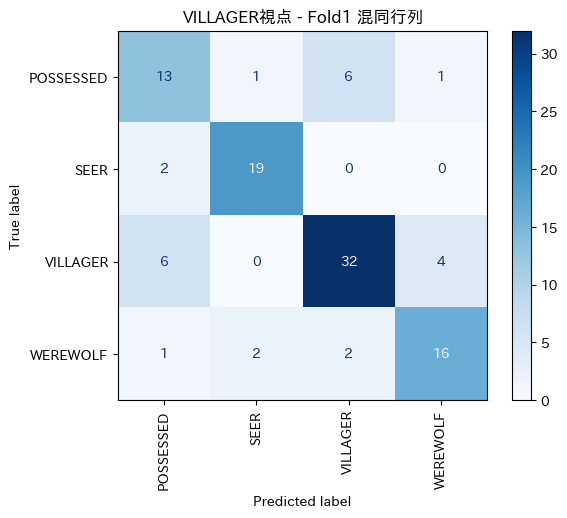


=== Fold 2 の詳細結果 ===
検証ゲーム数: 15

各ゲームのエージェントごとの予測結果（役職制約を満たす割り当て後）
※2人のVILLAGERが生存している場合、両方の視点から予測を取得

【Game 1 - VILLAGER視点: GPTaku1】
----------------------------------------------------------------------------------------------------
Agent                          Actual Role     Predicted (Direct)   Predicted (Assigned) Correct?  
----------------------------------------------------------------------------------------------------
Character-Lab1                 WEREWOLF        WEREWOLF             WEREWOLF             ✓         
CanisLupus1                    POSSESSED       WEREWOLF             POSSESSED            ✓         
CamelliaDragons1               SEER            SEER                 SEER                 ✓         
mille1                         VILLAGER        VILLAGER             VILLAGER             ✓         
GPTaku1                        VILLAGER        POSSESSED            VILLAGER             ✓         
---------------------------------------------------------------

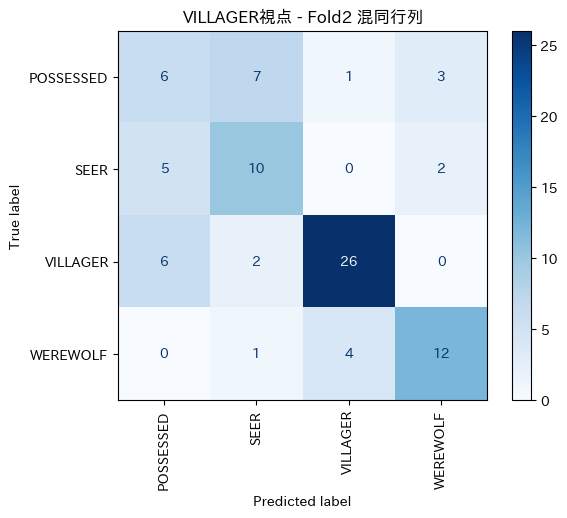


=== Fold 3 の詳細結果 ===
検証ゲーム数: 15

各ゲームのエージェントごとの予測結果（役職制約を満たす割り当て後）
※2人のVILLAGERが生存している場合、両方の視点から予測を取得

【Game 1 - VILLAGER視点: CanisLupus1】
----------------------------------------------------------------------------------------------------
Agent                          Actual Role     Predicted (Direct)   Predicted (Assigned) Correct?  
----------------------------------------------------------------------------------------------------
sunamelli1                     WEREWOLF        WEREWOLF             WEREWOLF             ✓         
mille1                         POSSESSED       SEER                 POSSESSED            ✓         
GPTaku1                        SEER            SEER                 SEER                 ✓         
Character-Lab1                 VILLAGER        VILLAGER             VILLAGER             ✓         
CanisLupus1                    VILLAGER        WEREWOLF             VILLAGER             ✓         
-----------------------------------------------------------

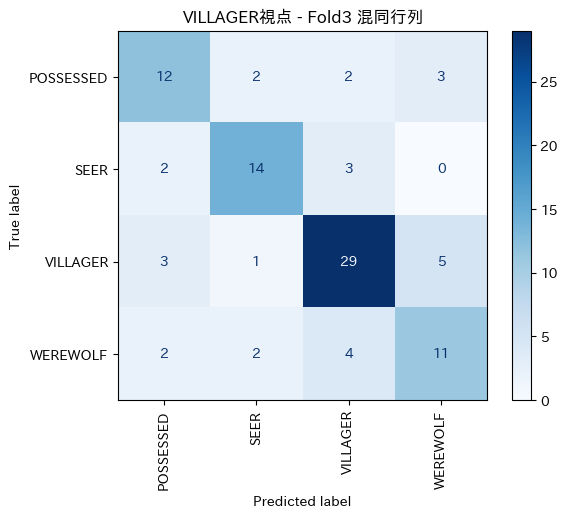


=== Fold 4 の詳細結果 ===
検証ゲーム数: 15

各ゲームのエージェントごとの予測結果（役職制約を満たす割り当て後）
※2人のVILLAGERが生存している場合、両方の視点から予測を取得

【Game 1 - VILLAGER視点: sunamelli1】
----------------------------------------------------------------------------------------------------
Agent                          Actual Role     Predicted (Direct)   Predicted (Assigned) Correct?  
----------------------------------------------------------------------------------------------------
GPTaku1                        VILLAGER        POSSESSED            POSSESSED            ✗         
sunamelli1                     VILLAGER        WEREWOLF             VILLAGER             ✓         
CamelliaDragons1               WEREWOLF        POSSESSED            WEREWOLF             ✓         
Character-Lab1                 POSSESSED       VILLAGER             VILLAGER             ✗         
CanisLupus1                    SEER            SEER                 SEER                 ✓         
------------------------------------------------------------

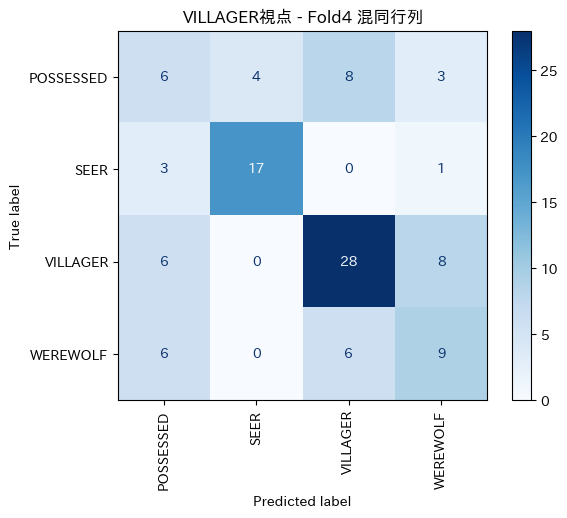


=== Fold 5 の詳細結果 ===
検証ゲーム数: 15

各ゲームのエージェントごとの予測結果（役職制約を満たす割り当て後）
※2人のVILLAGERが生存している場合、両方の視点から予測を取得

【Game 1 - VILLAGER視点: GPTaku1】
----------------------------------------------------------------------------------------------------
Agent                          Actual Role     Predicted (Direct)   Predicted (Assigned) Correct?  
----------------------------------------------------------------------------------------------------
CanisLupus1                    POSSESSED       POSSESSED            WEREWOLF             ✗         
Character-Lab1                 SEER            SEER                 SEER                 ✓         
GPTaku1                        VILLAGER        VILLAGER             VILLAGER             ✓         
sunamelli1                     VILLAGER        VILLAGER             VILLAGER             ✓         
mille1                         WEREWOLF        VILLAGER             POSSESSED            ✗         
---------------------------------------------------------------

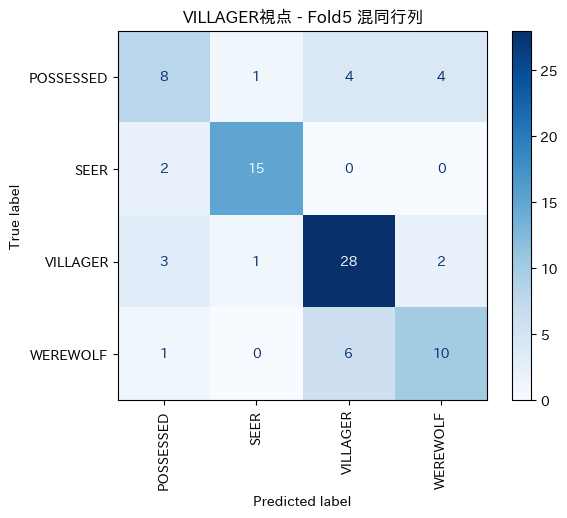

In [44]:
from sklearn.model_selection import StratifiedGroupKFold
import xgboost as xgb
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
import japanize_matplotlib

# VILLAGER視点モデルの全Foldでの詳細検証

print("=== VILLAGER視点モデル: 全Foldでの詳細検証 ===")

# 既存のVILLAGERモデルのパラメータを取得
models = joblib.load(r"C:\Users\takic\OneDrive\デスクトップ\修論関係(人狼知能)\役職推定\役職推定\XGB\CrossValidation\25夏\src\day2\start\werwolf_perspective_models_nospeaker.joblib")
villager_model = models["VILLAGER"]
best_params = villager_model.get_params()

# CV分割を再現
sgkf = StratifiedGroupKFold(n_splits=5)
groups = meta['source_file']

# クラス重み計算
classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)
weight_dict = dict(zip(classes, weights))

# 話者確率特徴量を事前計算
df_full = pd.DataFrame(X, columns=final_features)
df_full['combined_text'] = raw_texts
df_full['agent_name'] = agent_names
df_full_with_probs = compute_speaker_features_with_oof(df_full, n_splits=5)
prob_cols = [col for col in df_full_with_probs.columns if col.startswith('prob_class_')]
X_enhanced = np.hstack([X, df_full_with_probs[prob_cols].values])

# 全Foldを対象とした学習・検証
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    
    print(f"\n{'='*100}")
    print(f"=== Fold {fold + 1} の詳細結果 ===")
    print(f"{'='*100}")
    
    # 訓練・検証データの準備
    X_tr, X_val = X_enhanced[train_idx], X_enhanced[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    meta_val = {k: v[val_idx] for k, v in meta.items()}
    agent_names_val = agent_names[val_idx]
    
    # サンプル重み
    w_tr = np.array([weight_dict[label] for label in y_tr])
    
    # 新しくモデルを学習（このFold以外のデータで）
    model_fold = xgb.XGBClassifier(**best_params)
    model_fold.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    # 予測
    preds_proba = model_fold.predict_proba(X_val)
    
    # 役職割り当てロジックによる評価
    all_p, all_t = [], []
    num_games = len(y_val) // 5
    role_counts = {'POSSESSED': 1, 'SEER': 1, 'VILLAGER': 2, 'WEREWOLF': 1}
    class_names = list(label_encoder.classes_)
    
    print(f"検証ゲーム数: {num_games}")
    
    # 各ゲームの詳細結果を格納
    game_details = []
    
    for i in range(num_games):
        s, e = i*5, (i+1)*5
        
        # ゲームごとのデータ取得
        game_probs = preds_proba[s:e]
        game_true_labels = y_val[s:e]
        game_agents = agent_names_val[s:e]
        game_true_roles = label_encoder.inverse_transform(game_true_labels)
        game_pred_direct = label_encoder.inverse_transform(np.argmax(game_probs, axis=1))
        
        # assign_roles_for_non_seer を使用して VILLAGER 視点での割り当てを実行
        pred_others, true_others = assign_roles_for_non_seer(
            game_probs, 
            game_true_labels, 
            role_counts, 
            class_names, 
            label_encoder, 
            "VILLAGER",
            meta_val['exec_id'][s:e], 
            meta_val['attack_id'][s:e], 
            day2_flag=True,
            debag=False
        )
        
        # 実際にVILLAGERであるプレイヤーを見つける
        villager_indices = [idx for idx in range(5) if game_true_roles[idx] == "VILLAGER"]
        
        # 生存しているVILLAGERを全て取得
        exec_id = meta_val['exec_id'][s]
        attack_id = meta_val['attack_id'][s]
        alive_villager_indices = []
        
        for v_idx in villager_indices:
            if (v_idx + 1) not in [exec_id, attack_id]:  # player_idは1-indexed
                alive_villager_indices.append(v_idx)
        
        # 各生存VILLAGERの視点から予測を構築（2人いれば2回検査）
        predictions_count = 0
        
        for villager_idx_in_list, alive_villager_idx in enumerate(alive_villager_indices):
            if pred_others.size == 0:
                break
                
            game_pred_assigned = np.full(5, -1, dtype=int)  # -1で初期化
            
            # このVILLAGERの視点での予測（他の4人分）を取得
            # pred_others には各VILLAGERからの予測が4つずつ順番に格納されている
            start_idx = villager_idx_in_list * 4
            end_idx = start_idx + 4
            
            if end_idx <= len(pred_others):
                other_indices = [idx for idx in range(5) if idx != alive_villager_idx]
                
                # 他のプレイヤーに予測された役職を割り当て
                for j, other_idx in enumerate(other_indices):
                    game_pred_assigned[other_idx] = pred_others[start_idx + j]
                
                # VILLAGERプレイヤー自身の役職を設定
                villager_label = label_encoder.transform(["VILLAGER"])[0]
                game_pred_assigned[alive_villager_idx] = villager_label
                
                # -1（未割り当て）の場合は直接予測を使用
                for idx in range(5):
                    if game_pred_assigned[idx] == -1:
                        game_pred_assigned[idx] = np.argmax(game_probs[idx])
                
                game_pred_assigned_roles = label_encoder.inverse_transform(game_pred_assigned)
                
                # このVILLAGERの視点での予測を記録
                game_details.append({
                    'game_idx': i + 1,
                    'villager_perspective': game_agents[alive_villager_idx],  # どのVILLAGERの視点か
                    'agents': game_agents,
                    'actual_roles': game_true_roles,
                    'predicted_direct': game_pred_direct,
                    'predicted_assigned': game_pred_assigned_roles
                })
                
                # 全体統計用に蓄積
                all_p.extend(game_pred_assigned)
                all_t.extend(game_true_labels)
                
                predictions_count += 1
        
        # どのVILLAGERからも予測できなかった場合は直接予測を使用
        if predictions_count == 0:
            game_pred_assigned = np.full(5, -1, dtype=int)
            for idx in range(5):
                game_pred_assigned[idx] = np.argmax(game_probs[idx])
            
            game_pred_assigned_roles = label_encoder.inverse_transform(game_pred_assigned)
            
            game_details.append({
                'game_idx': i + 1,
                'villager_perspective': 'N/A (no alive villager)',
                'agents': game_agents,
                'actual_roles': game_true_roles,
                'predicted_direct': game_pred_direct,
                'predicted_assigned': game_pred_assigned_roles
            })
            
            # 全体統計用に蓄積
            all_p.extend(game_pred_assigned)
            all_t.extend(game_true_labels)
    
    # 各ゲームのエージェントごとの予測結果を表示
    print("\n" + "="*100)
    print("各ゲームのエージェントごとの予測結果（役職制約を満たす割り当て後）")
    print("※2人のVILLAGERが生存している場合、両方の視点から予測を取得")
    print("="*100)
    
    for game_detail in game_details:
        print(f"\n【Game {game_detail['game_idx']} - VILLAGER視点: {game_detail['villager_perspective']}】")
        print("-" * 100)
        print(f"{'Agent':<30} {'Actual Role':<15} {'Predicted (Direct)':<20} {'Predicted (Assigned)':<20} {'Correct?':<10}")
        print("-" * 100)
        
        for j, agent in enumerate(game_detail['agents']):
            actual = game_detail['actual_roles'][j]
            pred_direct = game_detail['predicted_direct'][j]
            pred_assigned = game_detail['predicted_assigned'][j]
            is_correct = "✓" if actual == pred_assigned else "✗"
            print(f"{agent:<30} {actual:<15} {pred_direct:<20} {pred_assigned:<20} {is_correct:<10}")
        
        print("-" * 100)
    
    # エージェントごとの統計を集計（割り当て結果を使用）
    print("\n" + "="*100)
    print("エージェント別の予測精度（役職制約を満たす割り当て後）")
    print("※2人のVILLAGERが生存している場合、同じエージェントが2回カウントされることがある")
    print("="*100)
    
    agent_stats = {}
    for game_detail in game_details:
        for j, agent in enumerate(game_detail['agents']):
            actual = game_detail['actual_roles'][j]
            pred = game_detail['predicted_assigned'][j]
            
            if agent not in agent_stats:
                agent_stats[agent] = {'correct': 0, 'total': 0, 'by_role': {}}
            
            agent_stats[agent]['total'] += 1
            if actual == pred:
                agent_stats[agent]['correct'] += 1
            
            if actual not in agent_stats[agent]['by_role']:
                agent_stats[agent]['by_role'][actual] = {'correct': 0, 'total': 0}
            
            agent_stats[agent]['by_role'][actual]['total'] += 1
            if actual == pred:
                agent_stats[agent]['by_role'][actual]['correct'] += 1
    
    # エージェント別の精度を表示（正解率順）
    sorted_agents = sorted(agent_stats.items(), key=lambda x: x[1]['correct']/x[1]['total'], reverse=True)
    
    print(f"\n{'Agent':<30} {'Accuracy':<15} {'Correct/Total':<15}")
    print("-" * 60)
    for agent, stats in sorted_agents:
        accuracy = stats['correct'] / stats['total'] * 100
        print(f"{agent:<30} {accuracy:>6.2f}%        {stats['correct']:>3}/{stats['total']:<3}")
    
    if len(all_t) > 0:
        # F1スコア計算（WEREWOLF検出性能）
        werewolf_id = label_encoder.transform(['WEREWOLF'])[0]
        f1_werewolf = f1_score(all_t, all_p, labels=[werewolf_id], average='macro', zero_division=0)
        
        print(f"\n" + "="*100)
        print("全体の統計情報")
        print("※2人のVILLAGERが生存している場合、両方の視点から検査されるため実ゲーム数より多くなる")
        print("="*100)
        print(f"検査数（視点数）: {len(all_t)}")
        print(f"実ゲーム数: {num_games}")
        print(f"WEREWOLF検出F1スコア: {f1_werewolf:.4f}")
        
        # 詳細な分類レポート
        print("\n分類レポート:")
        print(classification_report(all_t, all_p, labels=label_encoder.transform(class_names), 
                                  target_names=class_names, zero_division=0))
        
        # 混同行列
        ConfusionMatrixDisplay.from_predictions(
            all_t, all_p, labels=label_encoder.transform(class_names), 
            display_labels=class_names, cmap='Blues', xticks_rotation='vertical'
        )
        plt.title(f"VILLAGER視点 - Fold{fold + 1} 混同行列")
        plt.show()
        
    else:
        print("評価対象サンプルが見つかりませんでした")


In [12]:
from collections import Counter

# 各Foldの役職ごとのエージェント割り当てを集計
fold_agent_data = []

for fold in range(1, 6):
    fold_idx = np.where(np.isin(meta['source_file'], [meta['source_file'][i] for i in range(len(meta['source_file'])) if i in val_idx]))[0]
    
    # 各役職について
    for role in ['POSSESSED', 'SEER', 'VILLAGER', 'WEREWOLF']:
        role_encoded = label_encoder.transform([role])[0]
        
        # このFoldでこの役職を持つプレイヤーのインデックス
        role_indices_in_fold = [i for i in val_idx if y[i] == role_encoded]
        
        # エージェント名を取得
        agents_in_fold = agent_names[role_indices_in_fold]
        
        # エージェントごとにカウント
        agent_counts = Counter(agents_in_fold)
        
        # このFoldの検証データからexec_id, attack_idを取得
        for i in role_indices_in_fold:
            agent = agent_names[i]
            
            # このプレイヤーが属するゲームの情報を取得
            # プレイヤーIDは1始まり (インデックス % 5から算出)
            player_id_in_game = (i % 5) + 1
            game_start_idx = (i // 5) * 5
            
            # 同じゲーム内の全プレイヤーのexec_id, attack_idを取得
            exec_id = meta['exec_id'][game_start_idx]
            attack_id = meta['attack_id'][game_start_idx]
            
            # NaN対応: execまたはattackされた場合はスキップ
            is_executed = (not np.isnan(exec_id)) and (player_id_in_game == exec_id)
            is_attacked = (not np.isnan(attack_id)) and (player_id_in_game == attack_id)
            
            # 生存者のみカウント
            if not (is_executed or is_attacked):
                fold_agent_data.append({
                    'Fold': fold,
                    'Role': role,
                    'Agent': agent,
                    'Count': 1
                })

                # 注: 上記のループにバグがあります。val_idxはループ外で定義されていないため、
                # 各Foldごとに取得する必要があります。以下のように修正します:

                fold_agent_data = []

                for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups), start=1):
                    print(f"Processing Fold {fold}...")
                    
                    # このFoldの検証データに含まれるsource_fileを取得
                    fold_source_files = meta['source_file'][val_idx]
                    print(f"  Source files in Fold {fold}: {np.unique(fold_source_files)}")
                    
                    # 各役職について
                    for role in ['POSSESSED', 'SEER', 'VILLAGER', 'WEREWOLF']:
                        role_encoded = label_encoder.transform([role])[0]
                        
                        # このFoldでこの役職を持つプレイヤーのインデックス
                        role_indices_in_fold = [i for i in val_idx if y[i] == role_encoded]
                        
                        # 各プレイヤーについて生存判定
                        for i in role_indices_in_fold:
                            agent = agent_names[i]
                            
                            # プレイヤーIDは1始まり (ゲーム内での位置: 0-4 → ID: 1-5)
                            game_start_idx = (i // 5) * 5
                            player_id_in_game = (i % 5) + 1
                            
                            # 同じゲーム内の全プレイヤーのexec_id, attack_idを取得
                            exec_id = meta['exec_id'][game_start_idx]
                            attack_id = meta['attack_id'][game_start_idx]
                            
                            # NaN対応: execまたはattackされた場合はスキップ
                            is_executed = (not np.isnan(exec_id)) and (player_id_in_game == exec_id)
                            is_attacked = (not np.isnan(attack_id)) and (player_id_in_game == attack_id)
                            
                            # 生存者のみカウント
                            if not (is_executed or is_attacked):
                                fold_agent_data.append({
                                    'Fold': fold,
                                    'Role': role,
                                    'Agent': agent,
                                    'Count': 1
                                })
# DataFrameに変換
fold_agent_df = pd.DataFrame(fold_agent_data)

# ピボットテーブル形式で表示（見やすく）
print("=" * 80)
print("Fold別 役職別 エージェント割り当て集計")
print("=" * 80)

for fold in range(1, 6):
    print(f"\n{'='*60}")
    print(f"Fold {fold}")
    print(f"{'='*60}")
    
    fold_data = fold_agent_df[fold_agent_df['Fold'] == fold]
    pivot = fold_data.pivot_table(index='Agent', columns='Role', values='Count', fill_value=0, aggfunc='sum')
    print(pivot)
    print()

# 全体サマリー（全Fold合計）
print("\n" + "=" * 80)
print("全Fold合計 - 役職別エージェント割り当て")
print("=" * 80)
summary_pivot = fold_agent_df.pivot_table(index='Agent', columns='Role', values='Count', fill_value=0, aggfunc='sum')
print(summary_pivot)

# CSVとして保存
fold_agent_df.to_csv('fold_agent_assignment.csv', index=False)
summary_pivot.to_csv('agent_role_summary.csv')
print("\n結果を 'fold_agent_assignment.csv' と 'agent_role_summary.csv' に保存しました。")


Processing Fold 1...
  Source files in Fold 1: ['taged_1756134325_CamelliaDragons_CanisLupus_GPTaku_mille_sunamelli.log'
 'taged_1756183139_CamelliaDragons_CanisLupus_GPTaku_mille_sunamelli.log'
 'taged_1756192018_CamelliaDragons_Character-Lab_GPTaku_kanolab-nw_mille.log'
 'taged_1756194831_CamelliaDragons_CanisLupus_GPTaku_kanolab-nw_sunamelli.log'
 'taged_1756197842_CamelliaDragons_Character-Lab_kanolab-nw_mille_sunamelli.log'
 'taged_1756207395_CamelliaDragons_CanisLupus_GPTaku_kanolab-nw_sunamelli.log'
 'taged_1756215980_Character-Lab_GPTaku_mille_sunamelli_yharada.log'
 'taged_1756219129_CanisLupus_GPTaku_kanolab-nw_mille_sunamelli.log'
 'taged_1756223556_CamelliaDragons_CanisLupus_Character-Lab_kanolab-nw_mille.log'
 'taged_1756229556_CanisLupus_Character-Lab_kanolab-nw_sunamelli_yharada.log'
 'taged_1756238124_Character-Lab_GPTaku_kanolab-nw_sunamelli_yharada.log'
 'taged_1756244910_CamelliaDragons_CanisLupus_kanolab-nw_sunamelli_yharada.log'
 'taged_1756247740_Character-Lab_kan

In [9]:
models =joblib.load("werwolf_perspective_models.joblib")
seerview_model=models["SEER"]
v_and_p_model=models["VILLAGER"]
wolf_model=models["WEREWOLF"]

In [10]:
print("=" * 60)
print("話者推定の実行と結果表示（CV分割を使用）")
print("=" * 60)

sgkf = StratifiedGroupKFold(n_splits=5)
groups = meta['source_file']

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    df_train_fold = pd.DataFrame(X[train_idx], columns=final_features)
    df_train_fold['combined_text'] = raw_texts[train_idx]
    df_train_fold['agent_name'] = agent_names[train_idx]
    
    df_val_fold = pd.DataFrame(X[val_idx], columns=final_features)
    df_val_fold['combined_text'] = raw_texts[val_idx]
    df_val_fold['agent_name'] = agent_names[val_idx]
    
    # 訓練データから話者推定モデルを学習
    agent_le = LabelEncoder()
    agent_le.fit(df_train_fold['agent_name'])
    y_train = agent_le.transform(df_train_fold['agent_name'])
    
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=2000, token_pattern=None)
    tfidf_train = vectorizer.fit_transform(df_train_fold['combined_text'].astype(str)).toarray()
    tfidf_val = vectorizer.transform(df_val_fold['combined_text'].astype(str)).toarray()
    
    params = {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 42}
    model = xgb.XGBClassifier(**params, eval_metric='mlogloss')
    calibrated = CalibratedClassifierCV(estimator=model, cv=5)
    calibrated.fit(tfidf_train, y_train)
    
    # 検証データの予測
    y_val_pred = calibrated.predict(tfidf_val)
    y_val_true = agent_le.transform(df_val_fold['agent_name'])
    
    # Accuracyを計算
    fold_accuracy = accuracy_score(y_val_true, y_val_pred)
    cv_accuracies.append(fold_accuracy)
    print(f"Fold {fold + 1} Accuracy: {fold_accuracy:.4f}")

# 平均と標準偏差を計算・表示
mean_accuracy = np.mean(cv_accuracies)
std_accuracy = np.std(cv_accuracies)

print("\n" + "=" * 60)
print(f"平均 Accuracy: {mean_accuracy:.4f}")
print(f"標準偏差: {std_accuracy:.4f}")
print("=" * 60)


話者推定の実行と結果表示（CV分割を使用）
Fold 1 Accuracy: 0.9733
Fold 2 Accuracy: 0.8800
Fold 3 Accuracy: 0.9200
Fold 4 Accuracy: 0.8533
Fold 5 Accuracy: 0.8933

平均 Accuracy: 0.9040
標準偏差: 0.0408


# shap

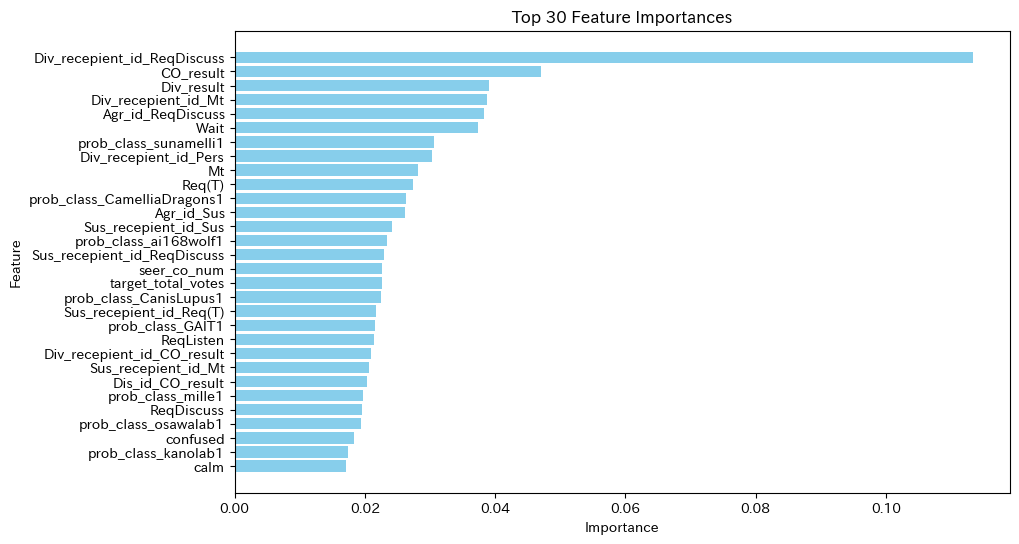

                         Feature  Importance
22   Div_recepient_id_ReqDiscuss    0.113326
161                    CO_result    0.047042
160                   Div_result    0.039069
37           Div_recepient_id_Mt    0.038696
112            Agr_id_ReqDiscuss    0.038343
..                           ...         ...
170            Est_id_Div_result    0.000000
173             Agr_id_CO_result    0.000000
172            Agr_id_Div_result    0.000000
174            Dis_id_Div_result    0.000000
176                    Fact_role    0.000000

[178 rows x 2 columns]
重要な特徴量:
{'Feature': {22: 'Div_recepient_id_ReqDiscuss', 161: 'CO_result', 160: 'Div_result', 37: 'Div_recepient_id_Mt', 112: 'Agr_id_ReqDiscuss', 6: 'Wait', 158: 'prob_class_sunamelli1', 36: 'Div_recepient_id_Pers', 15: 'Mt', 13: 'Req(T)', 150: 'prob_class_CamelliaDragons1', 124: 'Agr_id_Sus', 52: 'Sus_recepient_id_Sus', 154: 'prob_class_ai168wolf1', 40: 'Sus_recepient_id_ReqDiscuss', 18: 'seer_co_num', 148: 'target_total_votes', 15

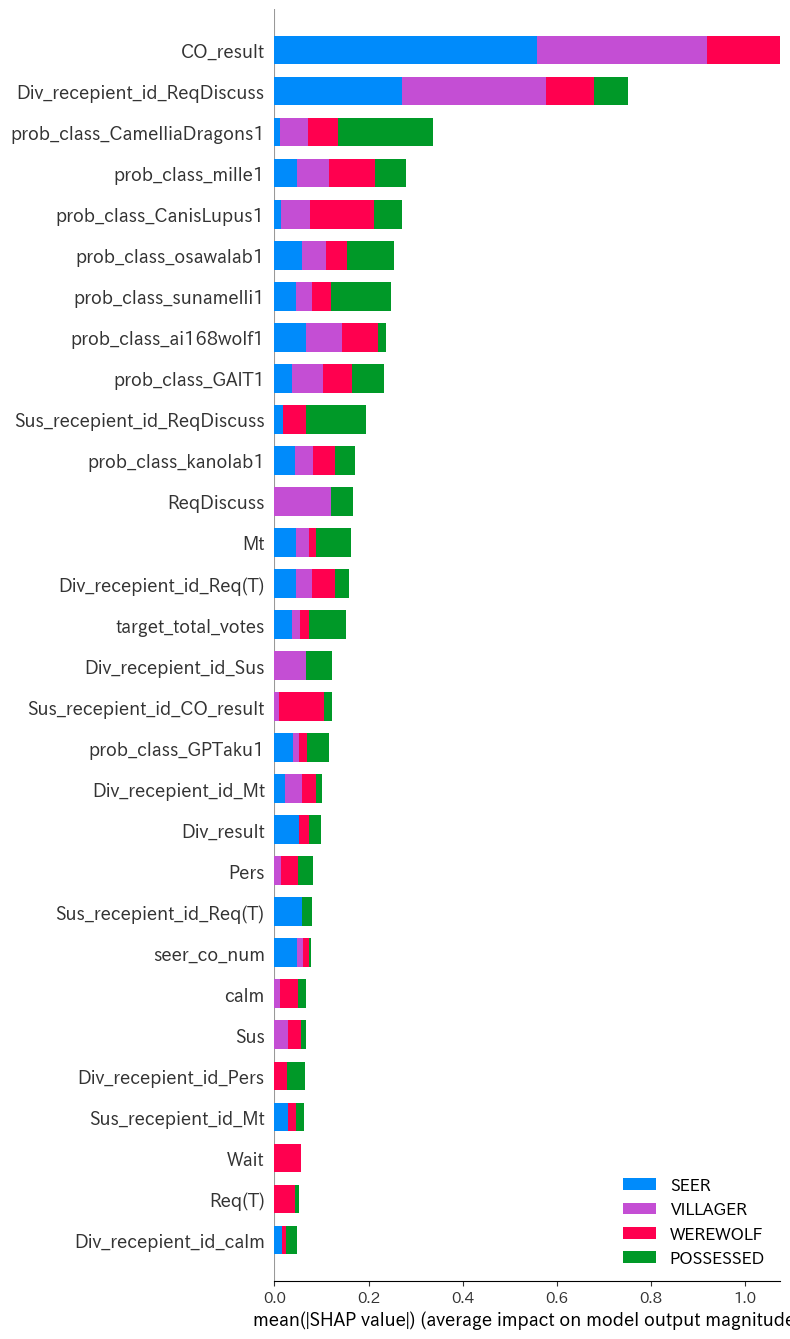

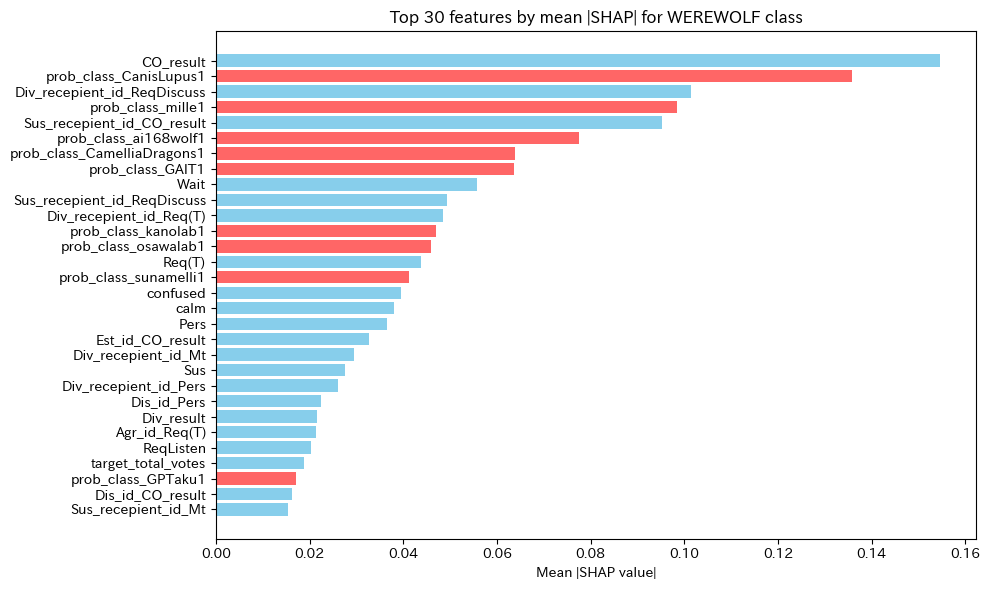

In [43]:
import pandas as pd
import shap

import matplotlib.pyplot as plt

# 特徴量重要度を取得
feature_importances = seerview_model.feature_importances_
# 例: XGBoostの場合
importance_gain = seerview_model.get_booster().get_score(importance_type='gain')
# 特徴量名と重要度をデータフレームにまとめる
importance_df = pd.DataFrame({
    'Feature': training_columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

importance_df_gain = pd.DataFrame({
    'Feature': [training_columns[int(f[1:])] for f in importance_gain.keys()],
    'Importance': list(importance_gain.values())
}).sort_values(by='Importance', ascending=False)

# 上位10個の特徴量をプロット
top_n = 30
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:top_n][::-1], importance_df['Importance'][:top_n][::-1], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 30 Feature Importances')
plt.show()

# 重要度データフレームを表示
print(importance_df)
important_features = importance_df[importance_df['Importance'] > 0]
print("重要な特徴量:")
print(important_features.to_dict())
not_zero_features=importance_df[importance_df['Importance'] > 0]['Feature'].tolist()
print("重要な特徴量の数:", len(not_zero_features))
train_df=pd.DataFrame(X_train, columns=training_columns)

# SHAPのExplainerを作成
explainer = shap.Explainer(wolf_model, train_df)

# SHAP値を計算
shap_values = explainer(train_df)

# LabelEncoderからクラス名（役職名）のリストを取得
# 例: ['Cursed', 'Knight', 'Medium', 'Seer', 'Villager', 'Werewolf'] のようなリストが返ります
class_names = label_encoder.classes_

# --- SHAPのSummary Plot (Bar) ---
# plot_type="bar" の場合、class_names を指定すると凡例が役職名になります
class_names = label_encoder.classes_
shap.summary_plot(
    shap_values, 
    train_df, 
    plot_type="bar", 
    max_display=top_n, 
    class_names=class_names, # ここで役職名を指定
    show=False
)

plt.show()
# --- SHAPのSummary Plot (Dot/Beeswarm) ---
# 多クラス分類のドットプロットは、通常「特定のクラス」に対して表示します。
# 例として「人狼 (Werewolf)」のインデックスが 5 の場合：
wolf_index = list(class_names).index("WEREWOLF")

prob_col_names = [col for col in training_columns if 'prob' in col]

# class-specific SHAP values for the target class
shap_arr = shap_values.values[:, :, wolf_index]  

# mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_arr).mean(axis=0)
feat_shap_df = pd.DataFrame({'Feature': training_columns, 'MeanAbsSHAP': mean_abs_shap})
feat_shap_df = feat_shap_df.sort_values('MeanAbsSHAP', ascending=False).head(top_n)

# color prob-features differently
colors = ['#ff6666' if f in prob_col_names else 'skyblue' for f in feat_shap_df['Feature']]

plt.figure(figsize=(10, 6))
plt.barh(feat_shap_df['Feature'][::-1], feat_shap_df['MeanAbsSHAP'][::-1], color=colors[::-1])
plt.xlabel('Mean |SHAP value|')
plt.title(f'Top {top_n} features by mean |SHAP| for WEREWOLF class')
plt.tight_layout()
plt.show()